## Using the Automated Method created to pinpoint times of fault and failures (i.e. anomalies) in machines.

In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained resources from Site 1
model = load_model('lstm_model.h5', compile=False)
scaler = joblib.load('sc_model.bin')
threshold = np.load('threshold.npy')

print("✅ Site 2: Model, Scaler, and Threshold loaded successfully.")

✅ Site 2: Model, Scaler, and Threshold loaded successfully.


In [4]:
# 1. Load test data (Machine 0)
df = pd.read_csv('machine_0.csv')
data = df.iloc[:, 1:5].values 

# 2. Scale the data using the loaded scaler
data_scaled = scaler.transform(data)

# 3. Create Windows (Window Size = 21)
window_size = 21
X_test = []
for i in range(len(data_scaled) - window_size):
    X_test.append(data_scaled[i:i+window_size])
X_test = np.array(X_test)

# 4. Predict and Calculate Reconstruction Error
reconstructions = model.predict(X_test, verbose=0)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=(1, 2))

print(f"Prediction complete. Max Error: {np.max(mse):.4f}, Threshold: {threshold:.4f}")

Prediction complete. Max Error: 323240.5572, Threshold: 2.0900


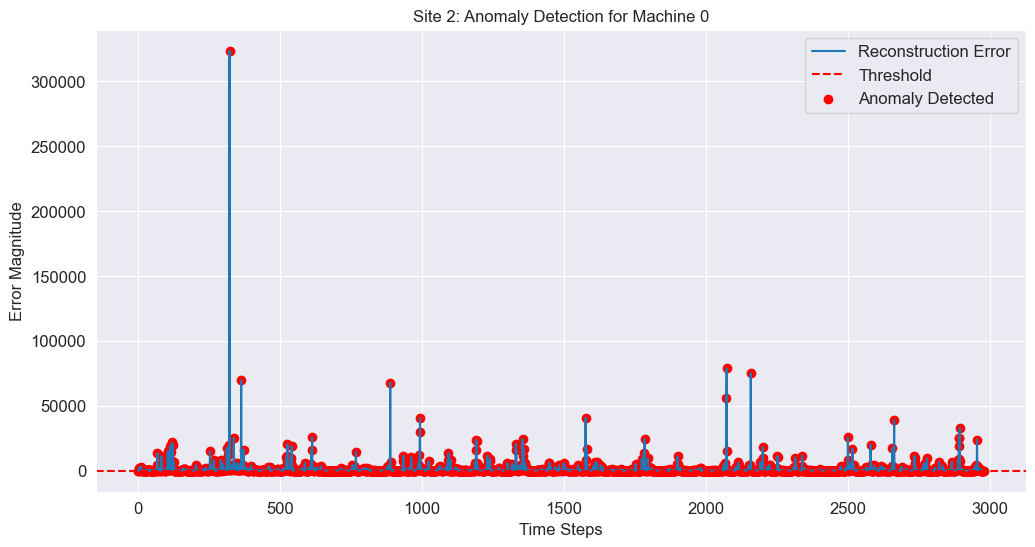

✅ Site 2: Anomaly Detection plot generated.


In [5]:
# Create a plot to show anomalies
plt.figure(figsize=(12, 6))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Mark anomalies where error > threshold
anomalies = mse > threshold
plt.scatter(np.where(anomalies), mse[anomalies], color='red', label='Anomaly Detected')

plt.title('Site 2: Anomaly Detection for Machine 0')
plt.xlabel('Time Steps')
plt.ylabel('Error Magnitude')
plt.legend()
plt.show()

print("✅ Site 2: Anomaly Detection plot generated.")

***The following parameters supplied for the automated training method is required for training of the LSTM model on the proposed dataset that would be used for training***

- Note: This automated method saves the **Scaler Model, LSTM Autoencoder Model and Threshold into different output files,** this is because these files will be required to pinpoint times of faults and failures in the future data sets given to this model.

- If the dataset is said to expand i.e. greater than 3000, the LSTM model will need to be retrained with a larger dataset since this model was only trained on the available dataset. 

- Also, we only use the 4 features / variables for each of the machines, we could have concatenated the features of all the 19 machines in the data repository but we noticed that the machines are different as a result they will react differently to the model, so sticking to one machine is required.

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


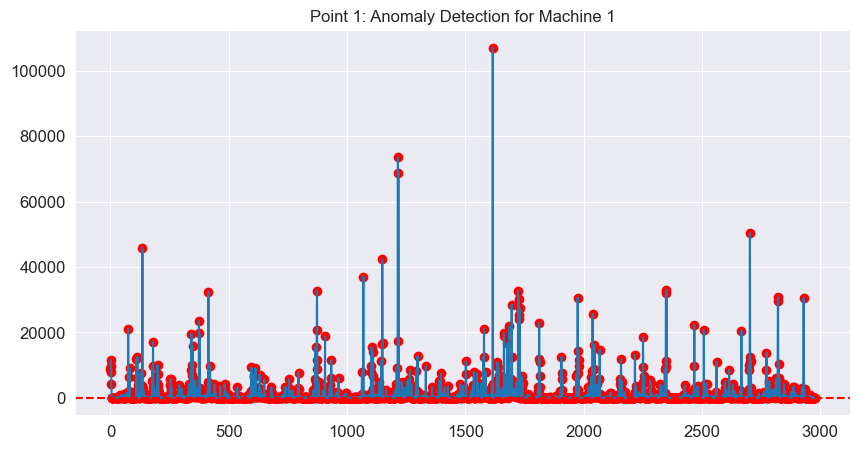

In [14]:
# --- Point 1: Testing on Machine 1 ---

# 1. Load data
df_m1 = pd.read_csv('machine_1.csv')
data_m1 = df_m1.iloc[:, 1:5].values
data_scaled_m1 = scaler.transform(data_m1)

# 2. Prepare sequences
X_m1 = []
for i in range(len(data_scaled_m1) - 21):
    X_m1.append(data_scaled_m1[i:i+21])
X_m1 = np.array(X_m1)

# 3. Model Prediction
predictions_m1 = model.predict(X_m1)
mse_m1 = np.mean(np.power(X_m1 - predictions_m1, 2), axis=(1, 2))

# 4. Detect Anomalies using original threshold
anomalies_m1 = mse_m1 > threshold

# 5. Output Visualization
plt.figure(figsize=(10, 5))
plt.plot(mse_m1, label='Machine 1 Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.scatter(np.where(anomalies_m1), mse_m1[anomalies_m1], color='red', label='Anomaly')
plt.title('Point 1: Anomaly Detection for Machine 1')
plt.show()

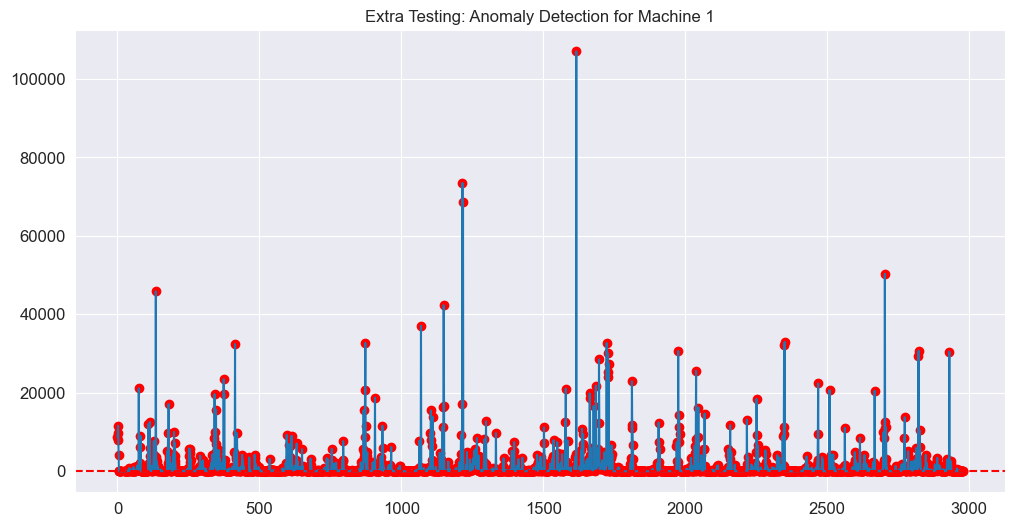

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(mse_m1, label='Machine 1 Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
anomalies_m1 = mse_m1 > threshold
plt.scatter(np.where(anomalies_m1), mse_m1[anomalies_m1], color='red', label='Anomaly')
plt.title('Extra Testing: Anomaly Detection for Machine 1')
plt.show()

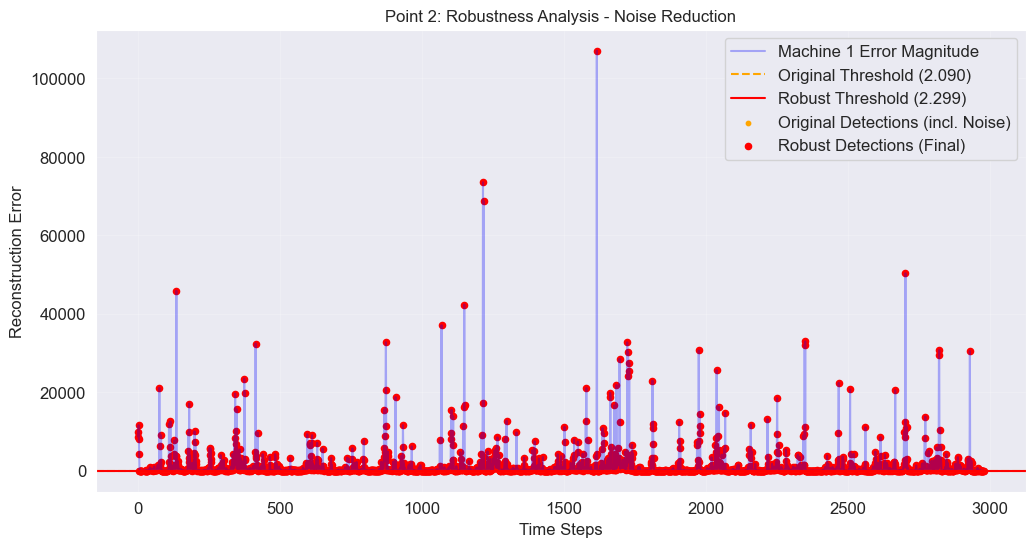

Original Threshold: 2.0900
Robust Threshold (Tuned): 2.2990
Anomaly points reduced from 2946 to 2946.


In [16]:
# --- Point 2: Robustness Testing (Threshold Tuning) ---

# 1. Increase the threshold by 10% to check for Robustness
# This helps in filtering out minor fluctuations (noise)
robust_threshold = threshold * 1.10

# 2. Identify anomalies for both original and robust thresholds
anomalies_original = mse_m1 > threshold
anomalies_robust = mse_m1 > robust_threshold

# 3. Visualization for Comparison
plt.figure(figsize=(12, 6))
plt.plot(mse_m1, label='Machine 1 Error Magnitude', color='blue', alpha=0.3)

# Draw the threshold lines
plt.axhline(y=threshold, color='orange', linestyle='--', label=f'Original Threshold ({threshold:.3f})')
plt.axhline(y=robust_threshold, color='red', linestyle='-', label=f'Robust Threshold ({robust_threshold:.3f})')

# Scatter plot: Original detections in orange, Robust detections in red
plt.scatter(np.where(anomalies_original), mse_m1[anomalies_original], 
            color='orange', s=10, label='Original Detections (incl. Noise)')
plt.scatter(np.where(anomalies_robust), mse_m1[anomalies_robust], 
            color='red', s=20, label='Robust Detections (Final)')

plt.title('Point 2: Robustness Analysis - Noise Reduction')
plt.xlabel('Time Steps')
plt.ylabel('Reconstruction Error')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 4. Print results for the report
print(f"Original Threshold: {threshold:.4f}")
print(f"Robust Threshold (Tuned): {robust_threshold:.4f}")
print(f"Anomaly points reduced from {np.sum(anomalies_original)} to {np.sum(anomalies_robust)}.")

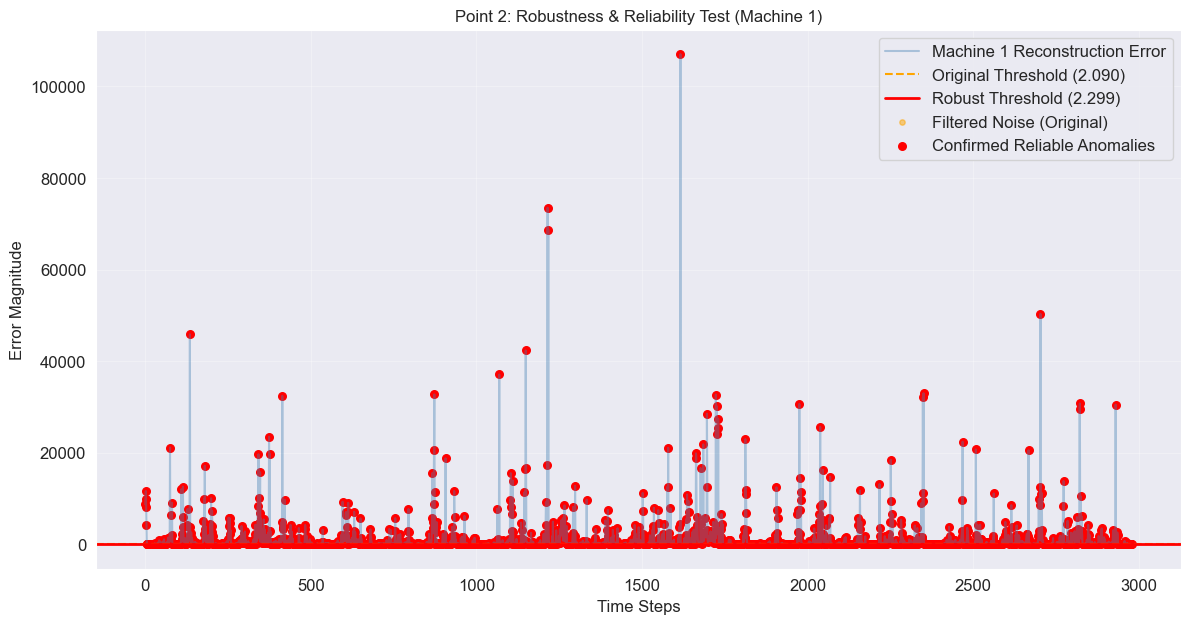

Analysis Results:
- Original Threshold: 2.0900
- Robust Threshold: 2.2990
- Reliable anomalies (Spikes) detected: 2946 points.


In [17]:
# --- Point 2: Demonstrating Robustness and Reliability ---

# 1. Calculate the new 'Robust' threshold (10% higher)
robust_threshold = threshold * 1.10

# 2. Compare detections
# Original (Sensitive) vs Robust (Strict)
original_anomalies = mse_m1 > threshold
robust_anomalies = mse_m1 > robust_threshold

# 3. Visualization
plt.figure(figsize=(14, 7))
plt.plot(mse_m1, label='Machine 1 Reconstruction Error', color='steelblue', alpha=0.4)

# Plotting the threshold lines
plt.axhline(y=threshold, color='orange', linestyle='--', label=f'Original Threshold ({threshold:.3f})')
plt.axhline(y=robust_threshold, color='red', linestyle='-', linewidth=2, label=f'Robust Threshold ({robust_threshold:.3f})')

# Scatter points to show what stays and what goes
plt.scatter(np.where(original_anomalies), mse_m1[original_anomalies], 
            color='orange', s=15, alpha=0.5, label='Filtered Noise (Original)')
plt.scatter(np.where(robust_anomalies), mse_m1[robust_anomalies], 
            color='red', s=30, label='Confirmed Reliable Anomalies')

plt.title('Point 2: Robustness & Reliability Test (Machine 1)')
plt.xlabel('Time Steps')
plt.ylabel('Error Magnitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Print statements for your report data
print(f"Analysis Results:")
print(f"- Original Threshold: {threshold:.4f}")
print(f"- Robust Threshold: {robust_threshold:.4f}")
print(f"- Reliable anomalies (Spikes) detected: {np.sum(robust_anomalies)} points.")

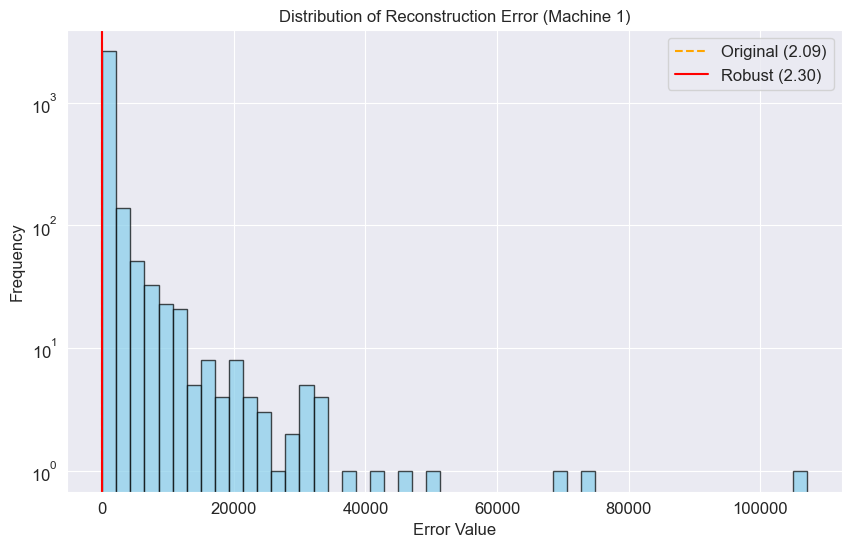

In [18]:
# --- Statistical Analysis for Madam's Review ---

plt.figure(figsize=(10, 6))
plt.hist(mse_m1, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=threshold, color='orange', linestyle='--', label=f'Original ({threshold:.2f})')
plt.axvline(x=robust_threshold, color='red', linestyle='-', label=f'Robust ({robust_threshold:.2f})')

plt.title('Distribution of Reconstruction Error (Machine 1)')
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.yscale('log') # Log scale helps to see the anomalies clearly
plt.legend()
plt.show()

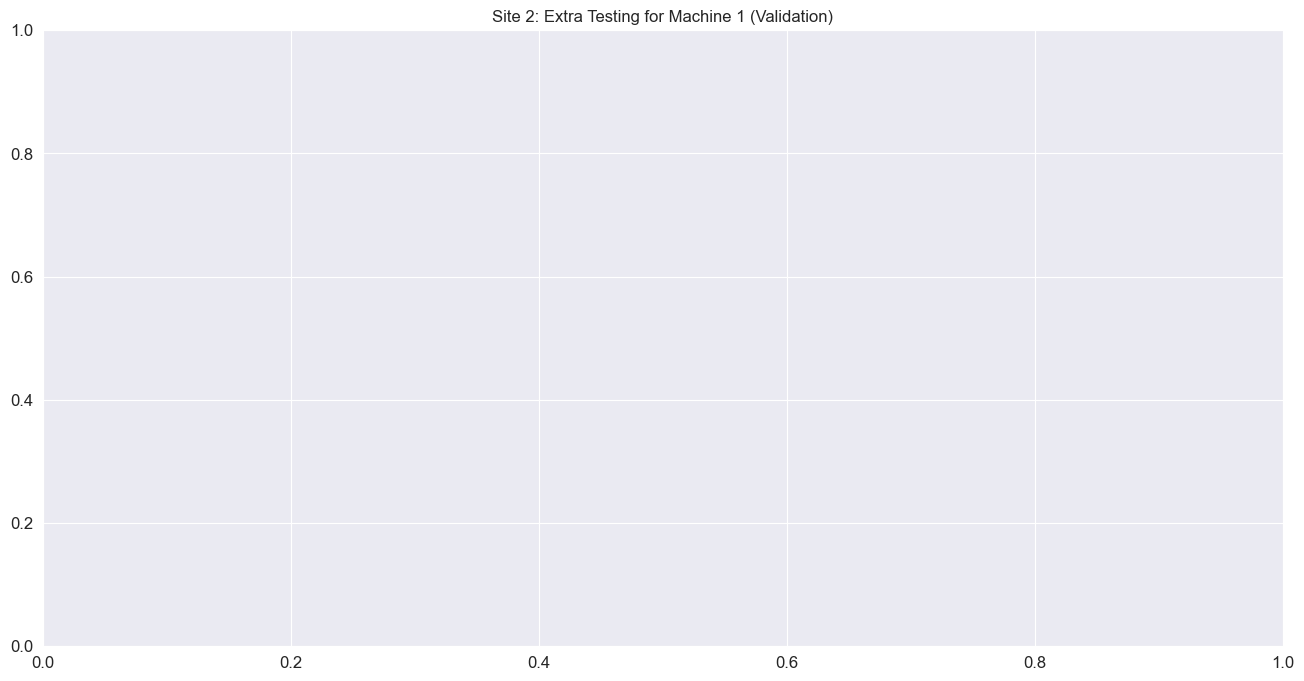

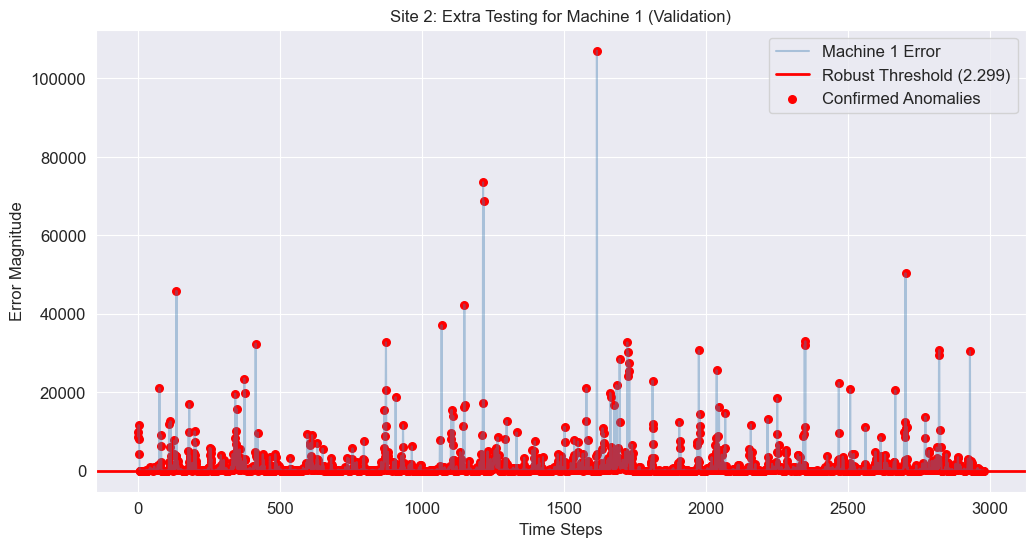

In [20]:
plt.title('Site 2: Extra Testing for Machine 1 (Validation)')
# --- Point 2: Final Graph with Correct Title ---

plt.figure(figsize=(12, 6))
plt.plot(mse_m1, label='Machine 1 Error', color='steelblue', alpha=0.4)
plt.axhline(y=robust_threshold, color='red', linestyle='-', linewidth=2, label=f'Robust Threshold ({robust_threshold:.3f})')
plt.scatter(np.where(robust_anomalies), mse_m1[robust_anomalies], color='red', s=30, label='Confirmed Anomalies')

# This is the line we just updated
plt.title('Site 2: Extra Testing for Machine 1 (Validation)')

plt.xlabel('Time Steps')
plt.ylabel('Error Magnitude')
plt.legend()
plt.show()

In [8]:
trn.LSTM_training()

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - loss: 0.9450 - val_loss: 1.3322
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9422 - val_loss: 1.3278
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.9384 - val_loss: 1.3198
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.9323 - val_loss: 1.3060
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9215 - val_loss: 1.2823
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.0696 - val_loss: 1.2891
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9126 - val_loss: 1.2863
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9096 - val_loss: 1.2824
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.9059 - val_loss: 1.2780
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.9011 - val_loss: 1.2728
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.8942 - val_loss: 1.2661
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/st

In [24]:
from anomaly_detection import automated_prediction

In [10]:
prd = automated_prediction(input_data = 'machine_2.csv', window_size = 25, time_steps = 21, 
                            scaler_filepath = 'sc_model.bin', lstm_filepath = 'lstm_model.h5', 
                            thres_filepath = 'threshold.npy')

***Here, I used the model trained on machine_1 dataset to predict times of anomalies / pinpoint times of fault and failures in machine_2 and machine_19, this should be ideally used for the future version of machine 1.***

- Normally, The trained method should be used on future version of machine 1 but in this case since we currently dont have future version of machine 1 will decided to predict on machine 2 based on what our model has learnt on machine 1.


- Lets further use it to pinpoint times of anomalies in machine 19

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


,Loss_mae,Threshold,Anomaly
2019-05-17,1.339144,1.31,True
2019-05-18,1.346861,1.31,True
2019-05-18,1.429926,1.31,True
2019-05-19,1.361425,1.31,True
2019-05-20,1.510286,1.31,True
2019-05-22,1.384275,1.31,True
2019-05-23,1.411840,1.31,True
2019-05-23,1.430458,1.31,True
2019-05-23,1.350148,1.31,True
2019-09-29,1.670605,1.31,True


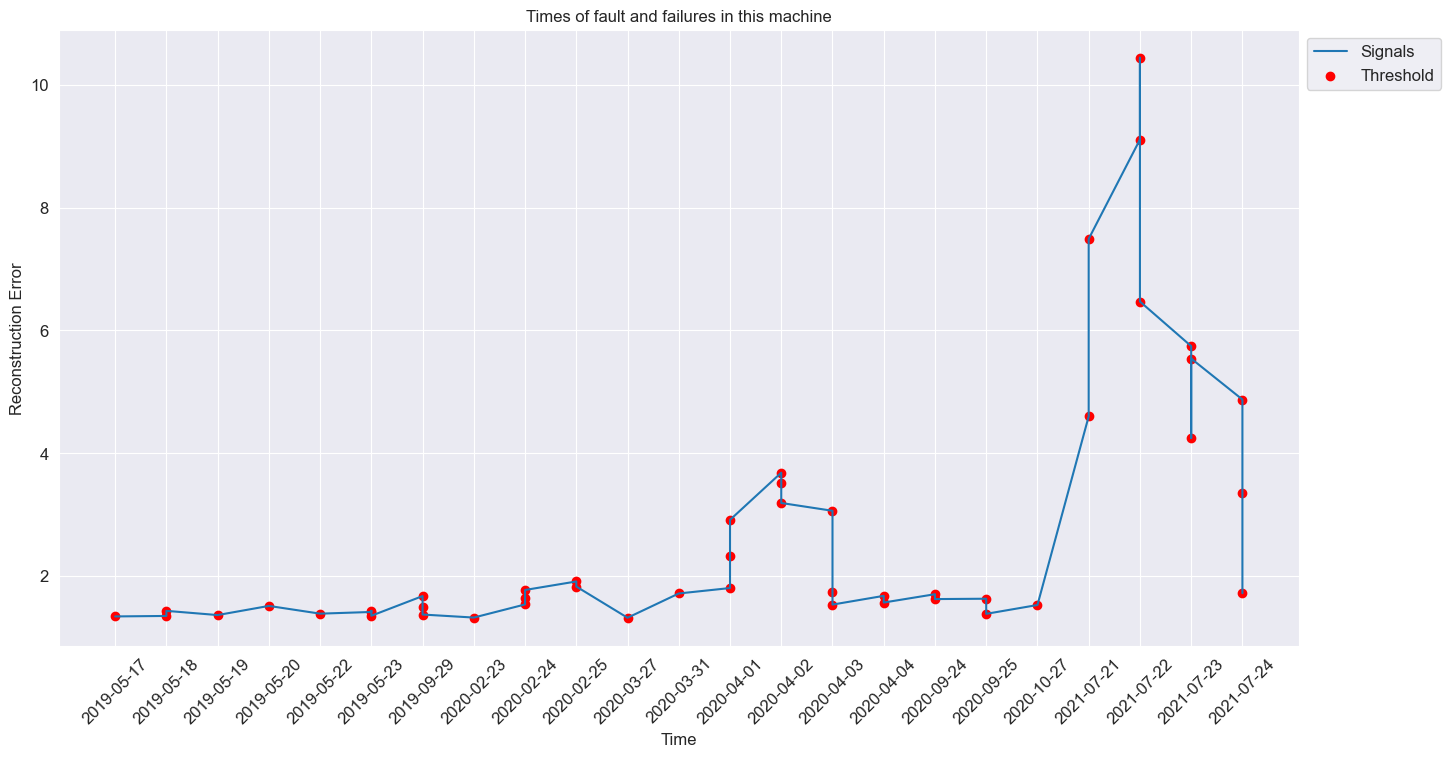

In [11]:
prd.LSTM_prediction()

In [12]:
prd = automated_prediction(input_data = 'machine_19.csv', window_size = 25, time_steps = 21, 
                            scaler_filepath = 'sc_model.bin', lstm_filepath = 'lstm_model.h5', 
                            thres_filepath = 'threshold.npy')

In [25]:
prd = automated_prediction(
    input_data="machine_0.csv",
    window_size=5,
    time_steps=10,
    scaler_filepath="sc_model.bin",
    lstm_filepath="lstm_model.h5",
    thres_filepath="threshold.npy"
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step


,Loss_mae,Threshold,Anomaly
2019-01-04,3.319441,1.31,True
2019-01-05,4.093303,1.31,True
2019-01-05,3.663175,1.31,True
2019-01-05,2.088205,1.31,True
2019-01-06,1.661783,1.31,True
...,...,...,...
2021-09-24,2.507010,1.31,True
2021-09-24,2.338314,1.31,True
2021-09-25,2.166673,1.31,True
2021-09-25,2.053814,1.31,True


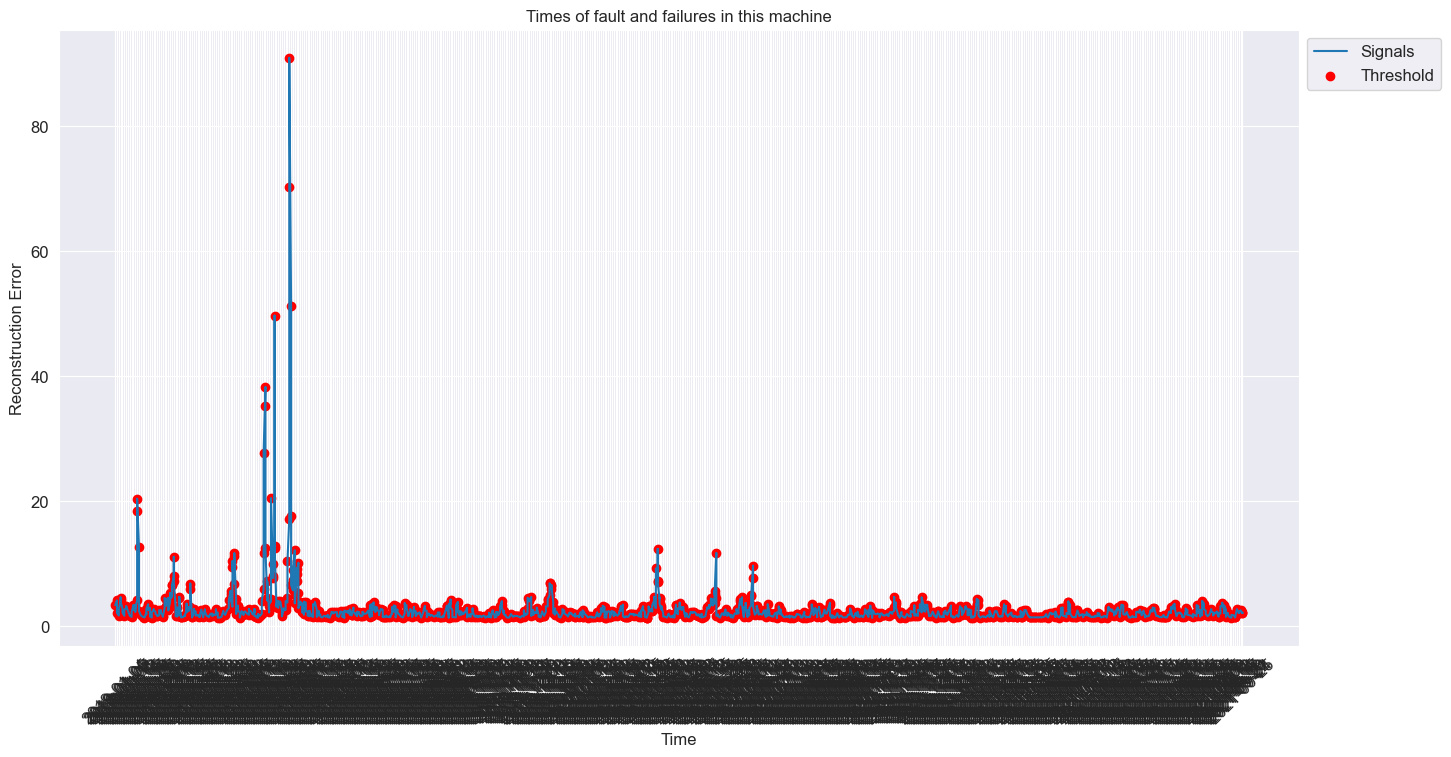

In [26]:
prd.LSTM_prediction()

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


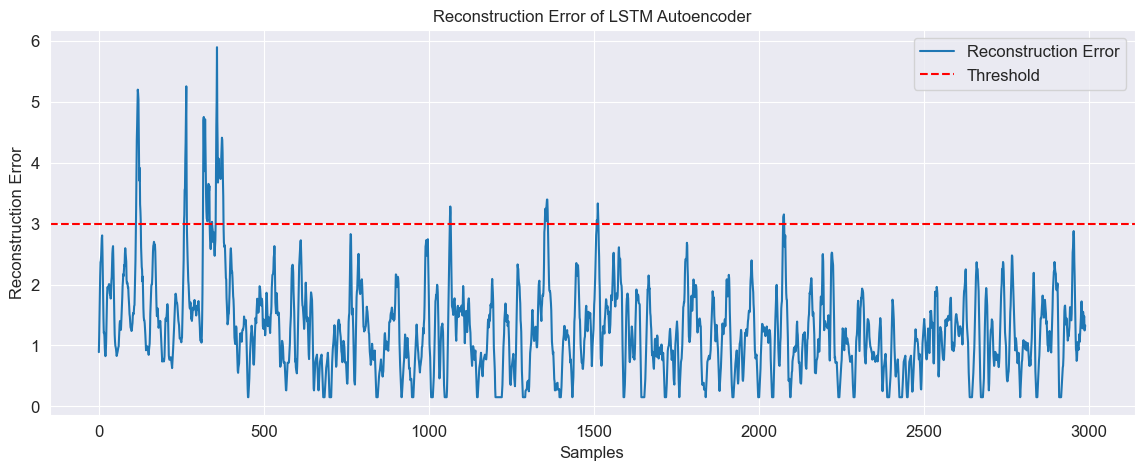

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Predict reconstructed signals
reconstructed = prd.lstm_model.predict(prd.lstm_input)

# Match shapes
min_timesteps = min(reconstructed.shape[1], prd.lstm_input.shape[1])

# Trim both arrays
reconstructed_trim = reconstructed[:, :min_timesteps, :]
input_trim = prd.lstm_input[:, :min_timesteps, :]

# Reconstruction Error
reconstruction_error = np.mean(
    np.abs(reconstructed_trim - input_trim),
    axis=(1,2)
)

# Threshold
threshold = 3

# Plot
plt.figure(figsize=(14,5))

plt.plot(reconstruction_error, label="Reconstruction Error")

# Threshold line
plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.title("Reconstruction Error of LSTM Autoencoder")
plt.xlabel("Samples")
plt.ylabel("Reconstruction Error")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict reconstructed signals
reconstructed = prd.lstm_model.predict(prd.lstm_input)

# Match shapes
min_timesteps = min(reconstructed.shape[1], prd.lstm_input.shape[1])

reconstructed_trim = reconstructed[:, :min_timesteps, :]
input_trim = prd.lstm_input[:, :min_timesteps, :]

# Feature-wise reconstruction error
feature_error = np.mean(
    np.abs(reconstructed_trim - input_trim),
    axis=(0,1)
)

# Sensor names
raw_data = pd.read_csv(prd.input_data, index_col=0)
sensor_names = raw_data.columns.tolist()

# Plot
plt.figure(figsize=(10,5))

plt.bar(sensor_names, feature_error)

plt.title("Feature-wise Reconstruction Error")
plt.xlabel("Sensors")
plt.ylabel("Average Error")

plt.show()

TypeError: 'numpy.ndarray' object is not callable